In [ ]:
!pip install scikit-optimize xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 9.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold
from skopt import BayesSearchCV
from xgboost import XGBRegressor

In [ ]:
df = pd.read_pickle('df_clusters.pkl')

In [ ]:
df.drop(columns='label', inplace=True)

In [ ]:
# prompt: drop every column with cluster in name

# Select columns to drop based on the keyword 'cluster'
columns_to_drop = [col for col in df.columns if 'cluster' in col.lower()]

# Drop the selected columns
df.drop(columns=columns_to_drop, inplace=True)

# Print the remaining columns to verify
df.columns

Index(['adult', 'based on novel or book', 'sequel', 'superhero',
       'based on comic', 'based on a true story', 'marvel',
       'director_Mel_Gibson', 'director_Sam_Taylor_Johnson',
       'director_Rodney_Rothman',
       ...
       'genre_Fantasy', 'genre_Horror', 'genre_Western',
       'genre_Science_Fiction', 'genre_Music', 'genre_Romance',
       'genre_Adventure', 'genre_Animation', 'runtime_log', 'target_value'],
      dtype='object', length=227)

In [ ]:
for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

In [ ]:
X = df.drop(columns=['target_value']).values
y = df['target_value'].values

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

In [ ]:
param_space = {
    'max_depth'        : (3, 10),
    'learning_rate'    : (0.01, 0.3, 'log-uniform'),
    'n_estimators'     : (50, 500),
    'subsample'        : (0.5, 1.0, 'uniform'),
    'colsample_bytree' : (0.5, 1.0, 'uniform'),
    'gamma'            : (0, 5, 'uniform'),
    'min_child_weight' : (1, 10),
    'reg_alpha'        : (1e-8, 1.0, 'log-uniform'),
    'reg_lambda'       : (1e-8, 1.0, 'log-uniform'),
}

In [ ]:
bayes_search = BayesSearchCV(
    estimator     = xgb,
    search_spaces = param_space,
    n_iter        = 30,
    scoring       = 'neg_root_mean_squared_error',
    cv            = cv,
    n_jobs        = -1,
    refit         = True,
    verbose       = 1
)

In [ ]:
bayes_search.fit(X, y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: Conv

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

BayesSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
              estimator=XGBRegressor(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='rmse', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     i...
              n_iter=30, n_jobs=-1, scoring='neg_root_mean_squared_error',
              search_spaces={'colsample_bytree': (0.5, 1.0, 'uniform'),
                             'gamma': (0, 5, 'uniform'),
                             'learning_rate': (0.01, 0.3, 'log-uniform'),
                             'max_depth': (3, 10), 'min_child_weight': (1, 10),
                             'n_estimators': (50, 500),
                             'reg_alpha': (1e-08, 1.0, 'log-uniform'),
                             'reg_lambda': (1e-08, 1.0, 'log-uniform'),
                             'subsample': (0.5, 1.0, 'uniform')},
              verbose=1)

In [ ]:
print("Najlepsze parametry:", bayes_search.best_params_)
print("Najlepszy CV RMSE:", -bayes_search.best_score_)

Najlepsze parametry: OrderedDict([('colsample_bytree', 0.9558685969175662), ('gamma', 4), ('learning_rate', 0.02245617933194391), ('max_depth', 4), ('min_child_weight', 2), ('n_estimators', 137), ('reg_alpha', 0.01804722821210677), ('reg_lambda', 0.0002293709013333687), ('subsample', 0.7106242336872417)])
Najlepszy CV RMSE: 1.221177793567738


In [ ]:
# prompt: podaj więcej miar dobroci modelu

import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Predykcje na danych treningowych (lub na zestawie walidacyjnym/testowym, jeśli dostępny)
y_pred = bayes_search.predict(X)

# Obliczanie dodatkowych miar dobroci modelu
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse) # RMSE jest już obliczane przez BayesSearchCV, ale można potwierdzić

print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}") # Powinno być bliskie wartości z best_score_

Mean Absolute Error (MAE): 0.9206576379936188
R-squared (R2): 0.13311917809163842
Mean Squared Error (MSE): 1.391846871750745
Root Mean Squared Error (RMSE): 1.1797656003421804


Ważność cech (SHAP summary plot):


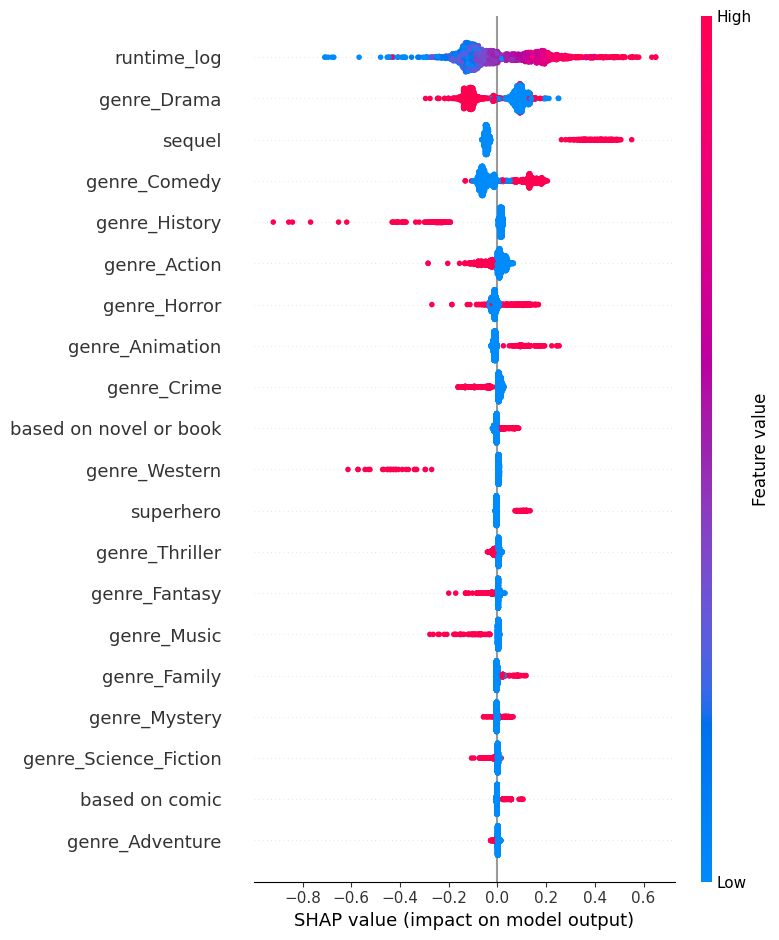


Top 15 najważniejszych cech (według średniej bezwzględnej wartości SHAP):
                    Feature  SHAP_Importance
225             runtime_log         0.131189
215             genre_Drama         0.099193
2                    sequel         0.078304
214            genre_Comedy         0.076472
210           genre_History         0.033317
213            genre_Action         0.025063
218            genre_Horror         0.023391
224         genre_Animation         0.020081
207             genre_Crime         0.018144
1    based on novel or book         0.009905
219           genre_Western         0.009656
3                 superhero         0.008322
211          genre_Thriller         0.008058
217           genre_Fantasy         0.007832
221             genre_Music         0.005844


In [ ]:
# %%
!pip install shap

# %%
import shap

# Utworzenie explainera SHAP
# Korzystamy z najlepszego wytrenowanego modelu z BayesSearchCV
explainer = shap.TreeExplainer(bayes_search.best_estimator_)

# Obliczenie wartości SHAP dla danych treningowych
shap_values = explainer.shap_values(X)

# Wizualizacja ważności cech (summary plot)
# To pokaże wpływ każdej cechy na predykcję
print("Ważność cech (SHAP summary plot):")
shap.summary_plot(shap_values, X, feature_names=df.drop(columns=['target_value']).columns)

# Aby uzyskać top 15 najważniejszych cech numerycznie:
# Średnia bezwzględna wartość SHAP dla każdej cechy
shap_abs_mean = np.abs(shap_values).mean(axis=0)

# Utworzenie DataFrame z ważnością cech
feature_importance_df = pd.DataFrame({
    'Feature': df.drop(columns=['target_value']).columns,
    'SHAP_Importance': shap_abs_mean
})

# Sortowanie i wyświetlenie top 15
top_15_features = feature_importance_df.sort_values(by='SHAP_Importance', ascending=False).head(15)

print("\nTop 15 najważniejszych cech (według średniej bezwzględnej wartości SHAP):")
print(top_15_features)

In [ ]:
# prompt: podaj wersje numpy i pandas

import pandas as pd
import numpy as np
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.0.2
Pandas version: 2.2.2
